In [18]:
from trainer import PPOTrainer, PPOConfig
from turan_env_c import CEnv, CHECKER_C3
from policies import make_policy
from profiler import PPOProfiler

In [35]:
n = 20
num_envs = 2048
checker_id = CHECKER_C3 
n_steps = 64
n_epochs= 10
batch_size = 2048
lr = 3e-4
gamma = 0.99
gae_lambda = 0.95
clip_eps = 0.2
vf_coef = 0.5
ent_coef = 0.01
max_grad_norm = 0.5
n_outer_steps = 4
total_steps = n_outer_steps*n_steps*num_envs
device = "cuda"
is_compile = True
# logging
log_interval = 10
save_interval = 100
# checkpointing
checkpoint_dir = "./checkpoints"
run_name = "n20_c3_edge_tformer"


env     = CEnv(n=n, num_envs=num_envs, checker_id=checker_id)
policy  = make_policy("edge_transformer", obs_dim=env.num_actions, action_dim=env.num_actions)
config = PPOConfig(n_steps,n_epochs,batch_size,lr,gamma,gae_lambda,
                   clip_eps,vf_coef,ent_coef,max_grad_norm,total_steps,
                   device,is_compile,log_interval,save_interval,checkpoint_dir,run_name)



In [36]:

trainer = PPOTrainer(env, policy, config=config)
trainer.fit()
env.close()


PPO  n=20  envs=2048  checker=0  device=cuda
policy: EdgeTransformerPolicy  params: 71,043
transitions/update: 131,072  total iters: 4
checkpoints: ./checkpoints/n20_c3_edge_tformer_*.pt

200 steps x 2048 envs in 0.04s
  10,419,177 steps/sec
  10.42M steps/sec



Done. best return: 35.98


In [37]:
from evaluate import load_policy, best_of_k, draw_graph, compare_k

In [44]:
# ── config ──
ckpt_path = f"{checkpoint_dir}/{run_name}_best.pt"
policy_name = "edge_transformer"   # must match what was trained
policy_kwargs = dict(d_model=64, n_heads=4, n_layers=2)
eval_n = 30
eval_checker = checker_id
eval_k = 1024

Loaded ./checkpoints/n20_c3_edge_tformer_best.pt  step=524,288  best_ret=35.98
best_of_1024: 65 edges  (min=65, mean=65.0, max=65)


<Axes: title={'center': 'C3-free  n=30  edges=65'}>

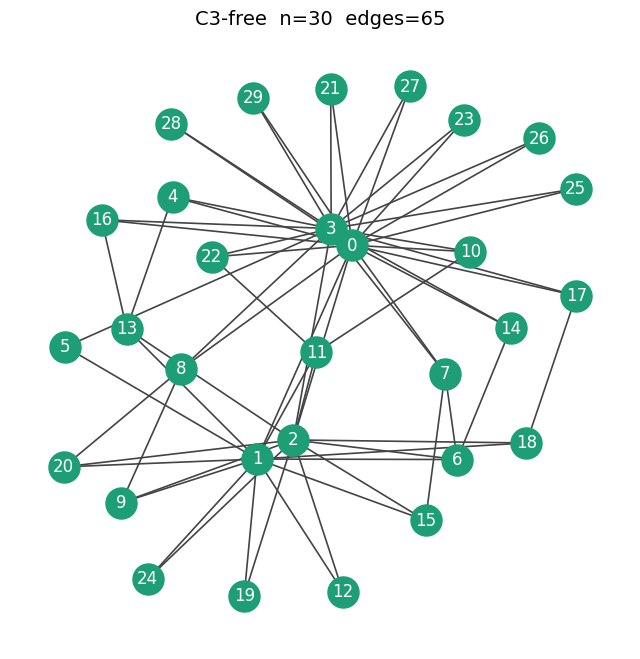

In [45]:
policy_eval, info = load_policy(ckpt_path, policy_name, **policy_kwargs)
obs, edges, G = best_of_k(policy_eval, eval_n, eval_checker, k=eval_k)
draw_graph(G, title=f"{'C3' if eval_checker==0 else 'C4'}-free  n={eval_n}  edges={edges}")

In [43]:
compare_k(policy_eval, eval_n, eval_checker, ks=(1, 8, 32, 128, 512))


     k    best      mean     min     max
------------------------------------------


     1      65      65.0      65      65
     8     200     200.0     200     200
    32      65      65.0      65      65
   128      65      65.0      65      65
   512      65      65.0      65      65
